<a href="https://colab.research.google.com/github/samiha-mahin/NLP/blob/main/NLP_Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## **What is NLP?**

**NLP (Natural Language Processing)** is a part of AI that helps computers understand human language (like English, Bangla, etc.).

In simple words:

NLP = Computer learning to read, understand, and reply to human text or speech.

---

## Easy Real-Life Examples

### Example 1 — Chatbot

When you talk to **ChatGPT**, it understands your message and replies.

You type:

> "How are you?"

Computer understands meaning → replies.

That understanding = NLP.

---

### Example 2 — Google Translate

You write:

> "I love you"

It translates to Bangla.

Understanding + translating language = NLP

---

### Example 3 — YouTube Recommendations

When you search:

> "sad songs"

It understands your words and shows related videos.

Understanding your text = NLP

---

## Super Simple Example

Sentence:

> "I love cats"

Computer cannot understand words.

So NLP converts it into something the computer understands:

"I" → word
"love" → emotion
"cats" → animal

Now computer knows the meaning.

---


NLP is a field of Artificial Intelligence that enables computers to understand, interpret, and generate human language.

---


## **What is Bag of Words (BoW)?**

Bag of Words = A way to convert text into numbers by counting words.

Computers don’t understand sentences, so we turn words into numbers.

 It only cares about:

* Which words appear
* How many times they appear

 It does NOT care about:

* Grammar
* Word order
* Meaning

That’s why it’s called a “bag” — words are just thrown inside like items in a bag.

---

## Easy Example

Sentences:

1. "I love cats"
2. "I love dogs"

### Step 1 — Make Vocabulary (all unique words)

Vocabulary =
I, love, cats, dogs

---

### Step 2 — Count words in each sentence

Sentence 1: "I love cats"

| I | love | cats | dogs |
| - | ---- | ---- | ---- |
| 1 | 1    | 1    | 0    |

Sentence 2: "I love dogs"

| I | love | cats | dogs |
| - | ---- | ---- | ---- |
| 1 | 1    | 0    | 1    |

Now the computer understands sentences as numbers.

---

## Why We Use Bag of Words

To train ML models for:

* Spam detection
* Sentiment analysis
* Text classification

---

## Super Simple Definition (Exam Style)

Bag of Words is a technique in NLP that represents text as numerical vectors based on word frequency, ignoring grammar and word order.

---

## One Problem of BoW

These two sentences become the same:

* "Dog bites man"
* "Man bites dog"

Because BoW ignores order.

---



**What does CountVectorizer do?**

CountVectorizer converts text into numbers by counting how many times each word appears.

It is used to create the **Bag of Words** representation.

It is from the Python ML library scikit-learn.

**Example 1**

In [1]:
from sklearn.feature_extraction.text import CountVectorizer

# Our sentences (documents)
sentences = [
    "I love cats",
    "I love dogs",
    "Cats and dogs both are cute but I love cats most"
]

# Create Bag of Words model
vectorizer = CountVectorizer()

# Convert text → numbers
bow = vectorizer.fit_transform(sentences)

# Show vocabulary (unique words)
print("Vocabulary:", vectorizer.get_feature_names_out())

# Show BoW matrix
print("BoW Matrix:\n", bow.toarray())


Vocabulary: ['and' 'are' 'both' 'but' 'cats' 'cute' 'dogs' 'love' 'most']
BoW Matrix:
 [[0 0 0 0 1 0 0 1 0]
 [0 0 0 0 0 0 1 1 0]
 [1 1 1 1 2 1 1 1 1]]


**Example 2**

In [2]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Sample dataset
X = [
    "Win money now",
    "Free prize waiting",
    "Claim your reward",
    "Congratulations you won",
    "Call me later",
    "Let's meet tomorrow",
    "Are you coming today",
    "Dinner tonight?",
    "Important update for you",
    "Limited offer just for you"
]

y = [1,1,1,1,0,0,0,0,1,1] # 1 = spam, 0 = not spam

# Bag of Words
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Model training
model = MultinomialNB()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.6666666666666666


**Example-3**

In [10]:
class Category :
    BOOKS = "BOOKS"
    CLOTHING = "CLOTHING"
train_x = ["i love the book", "this is a great book", "the fit is great", "i love the shoes"]
train_y = [Category.BOOKS, Category.BOOKS, Category.CLOTHING, Category.CLOTHING]

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(binary=True)
train_x_vectors = vectorizer.fit_transform(train_x)

print(vectorizer.get_feature_names_out())
print(train_x_vectors.toarray())


['book' 'fit' 'great' 'is' 'love' 'shoes' 'the' 'this']
[[1 0 0 0 1 0 1 0]
 [1 0 1 1 0 0 0 1]
 [0 1 1 1 0 0 1 0]
 [0 0 0 0 1 1 1 0]]


In [5]:
from sklearn import svm
clf_svm = svm.SVC(kernel='linear')
clf_svm.fit(train_x_vectors, train_y)


SVC(kernel='linear')

In [6]:
test_x = vectorizer.transform(['i like the book'])
clf_svm.predict(test_x)

array(['BOOKS'], dtype='<U8')

In **Bag of Words (BoW)**, text is converted into numbers by counting words.
To capture more context than single words, we use **n-grams**.

## 1. Unigram

A **unigram** means **single words**.

Example sentence:

> "I love machine learning"

Unigrams:

* I
* love
* machine
* learning

So the **Bag of Words vocabulary** becomes:

| Word     | Count |
| -------- | ----- |
| I        | 1     |
| love     | 1     |
| machine  | 1     |
| learning | 1     |

Meaning: the model only looks at **individual words**, not their relationships.

Problem:
The sentence **"not good"** might be interpreted as positive because it sees **good**.

---

## 2. Bigram

A **bigram** means **two consecutive words together**.

Example sentence:

> "I love machine learning"

Bigrams:

* I love
* love machine
* machine learning

Vocabulary example:

| Bigram           | Count |
| ---------------- | ----- |
| I love           | 1     |
| love machine     | 1     |
| machine learning | 1     |

Now the model captures **small context**.

Example:

Sentence:

> "not good"

Bigram:

* not good

Now the model understands that **not good = negative**.

---

## 3. N-gram

**N-gram** is the **general term**.

* Unigram → 1 word
* Bigram → 2 words
* Trigram → 3 words
* 4-gram → 4 words
* etc.

Example sentence:

> "I love machine learning very much"

### Unigrams

* I
* love
* machine
* learning
* very
* much

### Bigrams

* I love
* love machine
* machine learning
* learning very
* very much

### Trigrams

* I love machine
* love machine learning
* machine learning very
* learning very much

---

## Simple intuition

Unigram = **words**
Bigram = **word pairs**
Trigram = **3-word phrases**

The bigger the n-gram:

* more **context**
* but **larger vocabulary**
* more **memory and computation**

---

## In Scikit-Learn

Example:

```python
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(corpus)
```

`(1,2)` means:

* Unigrams
* Bigrams

---

## One-line summary

**Unigram:** single words
**Bigram:** two-word combinations
**N-gram:** sequence of *N* words used in Bag of Words to capture context.




# **Word Vectors and Dimensions (features)**

# 1. What is a Word Vector?

A **word vector** is a **list of numbers that represents a word** so that a computer can understand it.

Example word:

```
cat
```

Word vector:

```
cat → [0.21, 0.84, 0.10]
```

This list of numbers is called a **vector**.

---

# 2. What are Dimensions (Features)?

Each number in the vector represents a **feature (dimension) of the word**.

Example:

```
cat → [0.21, 0.84, 0.10]
```

This is a **3-dimensional word vector**.

| Dimension | Value |
| --------- | ----- |
| Feature 1 | 0.21  |
| Feature 2 | 0.84  |
| Feature 3 | 0.10  |

Each **dimension captures some property of the word** that the model learns automatically.

---

# 3. Simple Intuitive Example

Imagine the model learns these features:

| Feature   | Meaning              |
| --------- | -------------------- |
| Feature 1 | Animal vs Object     |
| Feature 2 | Living vs Non-living |
| Feature 3 | Size or behavior     |

Now look at the vectors.

| Word | Vector              |
| ---- | ------------------- |
| cat  | [0.21, 0.84, 0.10]  |
| dog  | [0.22, 0.80, 0.12]  |
| car  | [-0.60, 0.05, 0.90] |

### Observation

* **cat and dog vectors are similar**
* **car vector is very different**

So the computer understands that **cat and dog are similar words**.

---

# 4. Example With Sentence

Sentence:

```
cat drinks milk
```

Word vectors might be:

```
cat    → [0.21, 0.84, 0.10]
drinks → [0.50, 0.30, 0.60]
milk   → [0.18, 0.90, 0.20]
```

The sentence becomes numbers:

```
[
 [0.21,0.84,0.10],
 [0.50,0.30,0.60],
 [0.18,0.90,0.20]
]
```

Now a **machine learning model can process it**.

---

# 5. Real Word Vectors

In real models, vectors have **many dimensions**.

Examples:

| Model    | Dimensions |
| -------- | ---------- |
| Word2Vec | 100–300    |
| GloVe    | 100–300    |
| BERT     | 768        |

Example:

```
cat → [0.13, -0.52, 0.88, 0.44, ..., 768 values]
```

More dimensions = **more detailed meaning representation**.

---

# 6. Best One-Line Definition (for exams)

**Word vectors represent words as numerical vectors where each dimension is a learned feature capturing the semantic meaning of the word.**


In [7]:
!pip install -U spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 86.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [8]:
import spacy

nlp = spacy.load("en_core_web_sm")

doc = nlp("Apple is looking at buying a startup in the UK")

for token in doc:
    print(token.text, token.pos_)

Apple PROPN
is AUX
looking VERB
at ADP
buying VERB
a DET
startup NOUN
in ADP
the DET
UK PROPN


In [19]:
class Category :
    BOOKS = "BOOKS"
    CLOTHING = "CLOTHING"
train_x = ["i love the books", "this is a great book", "the fit is great", "i love the shoes"]
train_y = [Category.BOOKS, Category.BOOKS, Category.CLOTHING, Category.CLOTHING]

In [20]:
print(train_x)

['i love the books', 'this is a great book', 'the fit is great', 'i love the shoes']


In [21]:
docs = [nlp(text) for  text in train_x]
print(docs[0].vector)

[ 5.60366958e-02  1.17080778e-01 -3.94151360e-02 -3.89183760e-02
  2.16743931e-01 -2.99479932e-01  3.10907811e-01  5.54649830e-02
  5.00806868e-01 -2.75644958e-01 -4.61608052e-01  5.35077810e-01
  2.47213751e-01 -1.74088478e-01 -9.66994464e-02  4.23230171e-01
 -3.87834430e-01  5.30261993e-01 -2.62924314e-01 -3.95106614e-01
 -1.74451858e-01  1.30480081e-01 -3.89401615e-01 -2.20347971e-01
  7.11195916e-03 -3.01843524e-01 -4.16615605e-03  1.75142571e-01
 -8.61674845e-02  1.27968445e-01 -4.42032926e-02  2.52305269e-02
 -2.35582247e-01 -2.42029637e-01 -3.33254129e-01 -1.76150873e-01
 -3.05249095e-02  1.98978350e-01 -1.35840893e-01  8.29335570e-01
  1.29260123e-01  8.94278169e-01 -6.19839311e-01  5.51424697e-02
 -5.18684924e-01  1.31582692e-01 -8.74437392e-02  3.21976244e-01
  5.48880219e-01 -7.53950179e-02 -1.23043865e-01 -4.86933649e-01
  1.91490263e-01 -8.56754184e-03  6.62389919e-02 -5.81473529e-01
 -2.42534205e-02 -3.86849105e-01 -4.35835540e-01  7.50283897e-02
  1.01997107e-02 -1.02695

In [22]:
train_x_word_vectors = [x.vector for x in docs]

In [23]:
from sklearn import svm

clf_svm_wv = svm.SVC(kernel='linear')
clf_svm_wv.fit(train_x_word_vectors, train_y)

SVC(kernel='linear')

In [28]:
test_x = ["i like the books"]
test_docs = [nlp(text) for text in test_x]
test_x_word_vectors = [x.vector for x in test_docs]

clf_svm_wv.predict(test_x_word_vectors)

array(['BOOKS'], dtype='<U8')

# **TF-IDF (Term Frequency–Inverse Document Frequency)**

TF-IDF is a technique used in **Natural Language Processing (NLP)** to convert text into numbers while highlighting the most important words.

### Simple Idea

Imagine you have many documents:

**Document 1:** "I love cats"
**Document 2:** "I love dogs"
**Document 3:** "I love animals"

The word **"love"** appears in every document, so it is not very useful for distinguishing documents.

The words **"cats"**, **"dogs"**, and **"animals"** appear in only one document each, so they are more informative.

TF-IDF gives:

* **High score** → Important and unique words
* **Low score** → Common words that appear everywhere

---

## 1. TF (Term Frequency)

Measures how often a word appears in a document.


**TF = how many times a word appears in a document ÷ total number of words in that same document**



Example:

Document: **"cats cats dogs"**

* TF(cats) = 2/3 = 0.67
* TF(dogs) = 1/3 = 0.33

---

## 2. IDF (Inverse Document Frequency)

Measures how rare a word is across all documents.

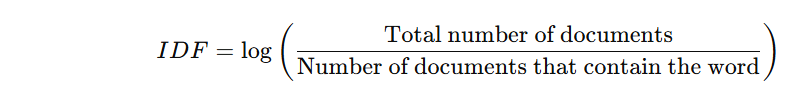

Example:

Suppose there are 3 documents:

* "love" appears in all 3 documents
* "cats" appears in only 1 document

Then:

* IDF(love) = low
* IDF(cats) = high

---

## 3. TF-IDF

Multiply TF and IDF:

**TF-IDF=TF×IDF**

A word gets a high TF-IDF score when:

* It appears many times in one document (**high TF**)
* It appears in few other documents (**high IDF**)

---

### Example

Documents:

1. "I love cats"
2. "I love dogs"
3. "I love animals"

| Word    | TF-IDF Importance |
| ------- | ----------------- |
| love    | Low               |
| cats    | High              |
| dogs    | High              |
| animals | High              |

Because "love" is everywhere, while the other words help identify each document.

---

### Why is TF-IDF used?

* Text Classification (Spam Detection, Sentiment Analysis)
* Document Search
* Information Retrieval
* Keyword Extraction
* Traditional Machine Learning models (SVM, Random Forest, Logistic Regression)

---

### One-line intuition

**TF-IDF tells the computer: "Give more importance to words that are frequent in this document but rare in other documents."**


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Sample documents
docs = [
    "I love machine learning",
    "I love deep learning",
    "machine learning is fun"
]

# Create TF-IDF model
vectorizer = TfidfVectorizer()

# Fit and transform the documents
tfidf_matrix = vectorizer.fit_transform(docs)

# Get feature names (words)
words = vectorizer.get_feature_names_out()

# Print results
print("Words:", words)
print("\nTF-IDF Matrix:\n", tfidf_matrix.toarray())

Words: ['deep' 'fun' 'is' 'learning' 'love' 'machine']

TF-IDF Matrix:
 [[0.         0.         0.         0.48133417 0.61980538 0.61980538]
 [0.72033345 0.         0.         0.42544054 0.54783215 0.        ]
 [0.         0.5844829  0.5844829  0.34520502 0.         0.44451431]]
